In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
df = pd.read_csv("C:/Users/91898/Desktop/salary pre/Salary Data.csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [67]:
df.tail()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0
374,44.0,Female,PhD,Senior Business Analyst,15.0,150000.0


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [69]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [70]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [71]:
df.duplicated().sum()

np.int64(50)

In [72]:
#there is 2 missing value in each column and also 50 duplicates values


In [73]:
#clear data

In [74]:
df = df.dropna()

In [75]:
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,Female,Bachelor's,Senior Marketing Analyst,8.0,85000.0
371,43.0,Male,Master's,Director of Operations,19.0,170000.0
372,29.0,Female,Bachelor's,Junior Project Manager,2.0,40000.0
373,34.0,Male,Bachelor's,Senior Operations Coordinator,7.0,90000.0


In [76]:
print("Before:", df.shape)

duplicates = df[df.duplicated()]
print(duplicates.head())

df = df.drop_duplicates()

print("After:", df.shape)

Before: (373, 6)
      Age  Gender Education Level                              Job Title  \
195  28.0    Male      Bachelor's                Junior Business Analyst   
250  30.0  Female      Bachelor's           Junior Marketing Coordinator   
251  38.0    Male        Master's                   Senior IT Consultant   
252  45.0  Female             PhD                Senior Product Designer   
253  28.0    Male      Bachelor's  Junior Business Development Associate   

     Years of Experience    Salary  
195                  2.0   40000.0  
250                  2.0   40000.0  
251                  9.0  110000.0  
252                 15.0  150000.0  
253                  2.0   40000.0  
After: (324, 6)


In [77]:
#eda

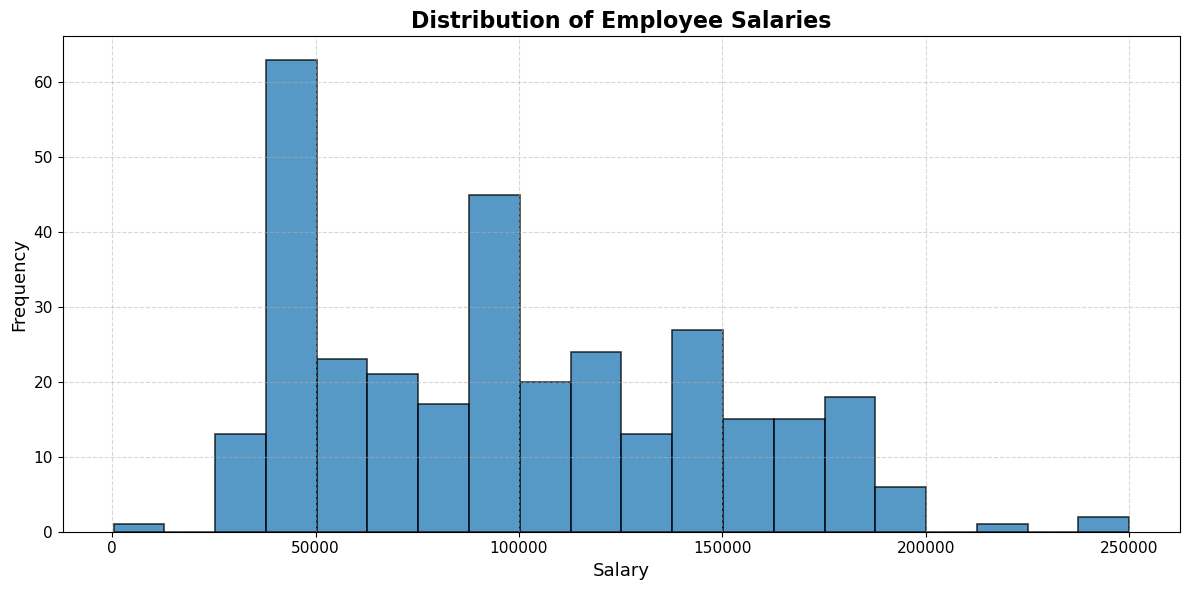

In [78]:
#Salary Distribution
plt.figure(figsize=(12, 6))

plt.hist(
    df['Salary'],
    bins=20,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.75
)

plt.xlabel('Salary', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.title('Distribution of Employee Salaries', fontsize=16, fontweight='bold')

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [79]:
df[df['Salary'] < 10000]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
259,29.0,Male,Bachelor's,Junior Business Operations Analyst,1.5,350.0


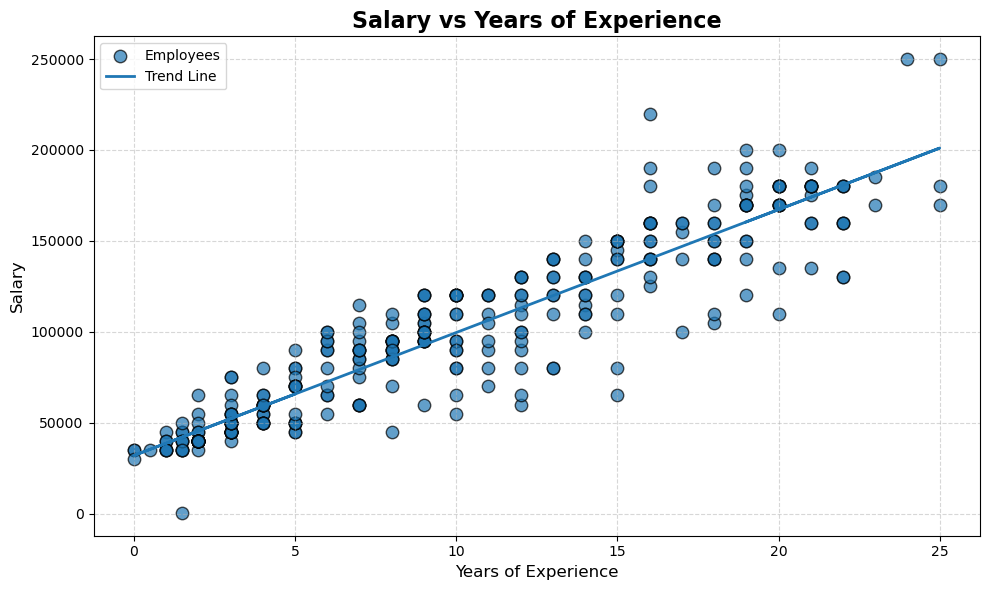

In [80]:
#Salary vs Years of Experience
plt.figure(figsize=(10, 6))
plt.scatter(
    df['Years of Experience'],
    df['Salary'],
    alpha=0.7,
    edgecolors='black',
    s=80,
    label='Employees'
)
z = np.polyfit(df['Years of Experience'], df['Salary'], 1)
p = np.poly1d(z)
plt.plot(
    df['Years of Experience'],
    p(df['Years of Experience']),
    linewidth=2,
    label='Trend Line'
)
plt.title('Salary vs Years of Experience', fontsize=16, fontweight='bold')
plt.xlabel('Years of Experience', fontsize=12)
plt.ylabel('Salary', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [81]:
df.groupby('Gender')['Salary'].mean()

Gender
Female     96136.363636
Male      103472.647059
Name: Salary, dtype: float64

In [82]:
df.groupby('Education Level')['Salary'].mean()

Education Level
Bachelor's     73902.356021
Master's      127912.087912
PhD           158095.238095
Name: Salary, dtype: float64

In [83]:
df.groupby('Job Title')['Salary'].mean().sort_values(ascending=False).head()

Job Title
CEO                         250000.0
Chief Technology Officer    250000.0
Chief Data Officer          220000.0
Director                    200000.0
VP of Finance               200000.0
Name: Salary, dtype: float64

In [84]:
df[['Age','Years of Experience','Salary']].corr()

,Age,Years of Experience,Salary
Age,1.000000,0.979192,0.916543
Years of Experience,0.979192,1.000000,0.924455
Salary,0.916543,0.924455,1.000000


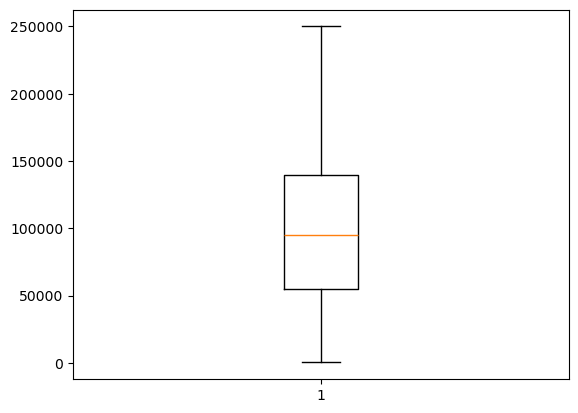

In [85]:
#outliers
plt.boxplot(df['Salary'])
plt.show()

In [86]:
print(df['Salary'].min())
print(df['Salary'].max())

350.0
250000.0


In [87]:
df[df['Salary'] == 350]

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
259,29.0,Male,Bachelor's,Junior Business Operations Analyst,1.5,350.0


In [88]:
#remove it
df = df[df['Salary'] != 350]

In [89]:
print(df['Salary'].min())

30000.0


In [90]:
#check data before train and test
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nSalary Range:")
print("Min:", df['Salary'].min())
print("Max:", df['Salary'].max())

Shape: (323, 6)

Missing Values:
Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

Duplicate Rows:
0

Data Types:
Age                    float64
Gender                  object
Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object

Salary Range:
Min: 30000.0
Max: 250000.0


In [91]:
#Feature Engineering
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
c_f = ['Gender', 'Education Level', 'Job Title']
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
         c_f) 
    ],
     remainder='passthrough'
)
X = df.drop('Salary', axis=1)
y = df['Salary']

X = preprocessor.fit_transform(X)

In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (258, 178)
Test Shape: (65, 178)


In [93]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [94]:
y_pred = lr.predict(X_test)

print(y_pred[:5])

[ 69283.65140901 112056.5670374  109210.94025294 118610.53844317
 109507.49170096]


In [95]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test,y_pred)
rmse = mean_squared_error(y_test,y_pred)**0.5
r2 = r2_score(y_test,y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 12547.917352901088
RMSE: 16176.88118794217
R2 Score: 0.8661631220843141


In [97]:
#other model
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)

In [98]:
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = mean_squared_error(
    y_test,
    y_pred_rf
) ** 0.5

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE : 9792.046886446886
RMSE: 14333.9831369919
R2 Score: 0.8949200194143824


In [100]:
import joblib

joblib.dump(rf, 'salary_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

In [101]:
model = joblib.load('salary_model.pkl')
encoder = joblib.load('preprocessor.pkl')

print("Loaded Successfully")

Loaded Successfully
